In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [ ]:
import os
import sys
import HeST as hest
# import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle
import scipy
import glob
import pandas

plt.rcParams.update({'font.size': 14})

In [4]:

amps = np.load('./data/Double_pulse_amps.npy')
cpd_1_evap = amps[:,1]
cpd_2_scint = amps[:,2]
cpd_2_evap = amps[:,3]

In [5]:
# np.shape(amps)
# mask = amps[:,1]>0
# cpd_1_evap = amps[:,1][mask]
# cpd_2_evap = amps[:,3][mask]

# # quick cuts now


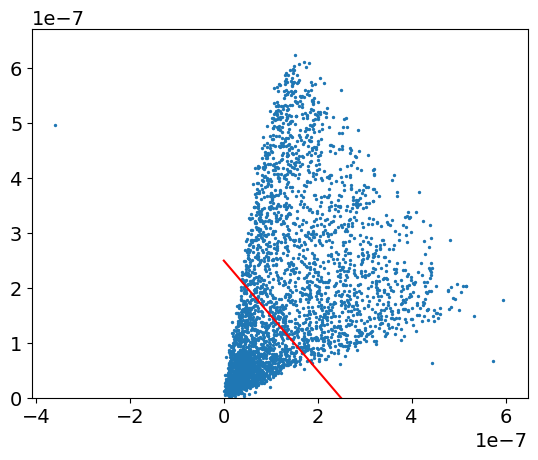

In [6]:
plt.scatter(cpd_1_evap, cpd_2_evap, s = 2)
# make cuts to get rid of aluminum blob (I think)
def linear(x,a,b):
    return a * x + b
c1 = -1
c2 = 2.5e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.ylim(0, )


al_blob_cut = cpd_2_evap > linear(cpd_1_evap, c1, c2)

(0.0, 6e-07)

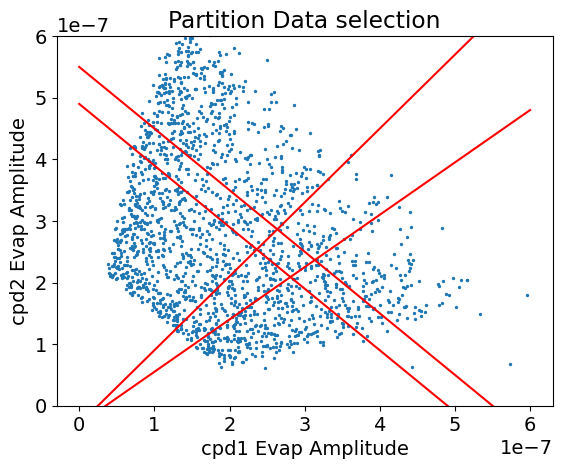

In [7]:
plt.scatter(cpd_1_evap[al_blob_cut], cpd_2_evap[al_blob_cut], s=2)
c1 = 1.2
c2 = -0.3e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.plot(x, linear(x, 0.85, -0.3e-7), 'r')


c1 = -1
c2 = 4.9e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')

c1 = -1
c2 = 5.5e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.ylim(0, )
plt.xlabel('cpd1 Evap Amplitude')
plt.ylabel('cpd2 Evap Amplitude')
plt.title('Partition Data selection')
plt.ylim(0, 0.6e-6)

In [8]:
params_1 = (1.2, -0.3e-7)
params_3 = (-1,  5.5e-7)
params_2 = (0.8, -0.3e-7)
params_4 = (-1, 4.9e-7)
cpd_2_evap = amps[:,3]
cpd_1_evap = amps[:,1]




# going to write the exclusion now. 
above_mask = (cpd_2_evap > linear(cpd_1_evap, *params_1)) | (cpd_2_evap > linear(cpd_1_evap, *params_3))
below_mask = (cpd_2_evap < linear(cpd_1_evap, *params_2)) | (cpd_2_evap < linear(cpd_1_evap, *params_4))

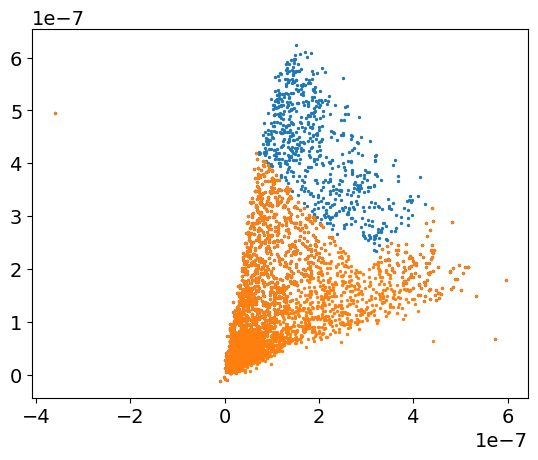

In [9]:
plt.scatter(cpd_1_evap[above_mask], cpd_2_evap[above_mask], s=2)

plt.scatter(cpd_1_evap[below_mask], cpd_2_evap[below_mask], s=2)

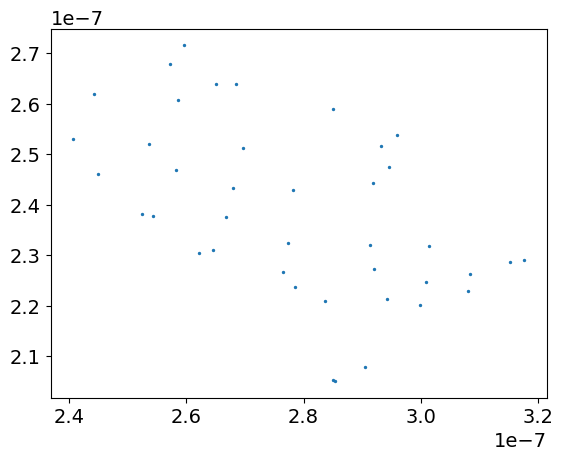

In [10]:
total_mask = above_mask | below_mask


plt.scatter(cpd_1_evap[~total_mask], cpd_2_evap[~total_mask], s=2)

# Load in everything


In [11]:
waves = np.load('./data/Double_pulse_wfs.npy')

amps = np.load('./data/Double_pulse_amps.npy')
cpd_1_evap = amps[:,1]
cpd_2_scint = amps[:,2]
cpd_2_evap = amps[:,3]



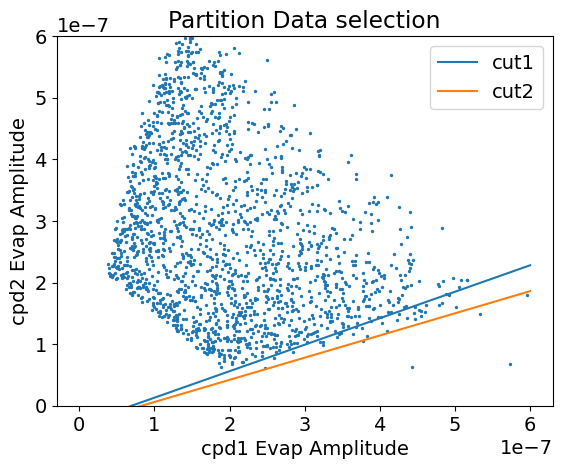

In [12]:
plt.scatter(cpd_1_evap[al_blob_cut], cpd_2_evap[al_blob_cut], s=2)
params1 = (0.43, -0.3e-7)
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,*params1), label = 'cut1')
params2 = (0.36, -0.3e-7)
plt.plot(x, linear(x, *params2), label = 'cut2')


c1 = -1
c2 = 4.9e-7
x = np.linspace(0,6e-7,100)
# plt.plot(x, linear(x,c1,c2), label = 'cut3')

c1 = -1
c2 = 5.5e-7
x = np.linspace(0,6e-7,100)
# plt.plot(x, linear(x,c1,c2), label='cut4')
plt.ylim(0, )
plt.xlabel('cpd1 Evap Amplitude')
plt.ylabel('cpd2 Evap Amplitude')
plt.title('Partition Data selection')
plt.ylim(0, 0.6e-6)
plt.legend()

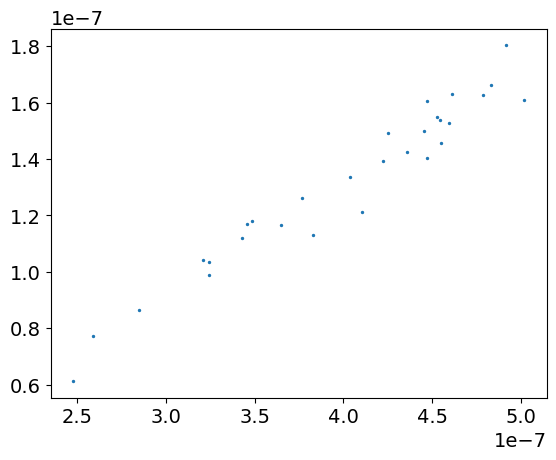

In [13]:
above_mask = (cpd_2_evap < linear(cpd_1_evap, *params1)) & (cpd_2_evap > linear(cpd_1_evap, *params2)) & (cpd_1_evap > 2e-7)
plt.scatter(cpd_1_evap[above_mask], cpd_2_evap[above_mask], s= 2)

In [14]:
def running_average(N, data):
    if N <= 0:
        raise ValueError("N must be a positive integer")
    
    data = np.array(data)
    cumsum = np.cumsum(data)
    result = cumsum.copy()
    
    result[N:] = (cumsum[N:] - cumsum[:-N]) / N
    result[:N] = cumsum[:N] / np.arange(1, N + 1)
    
    return result

# Template for good Channel (CPD2)

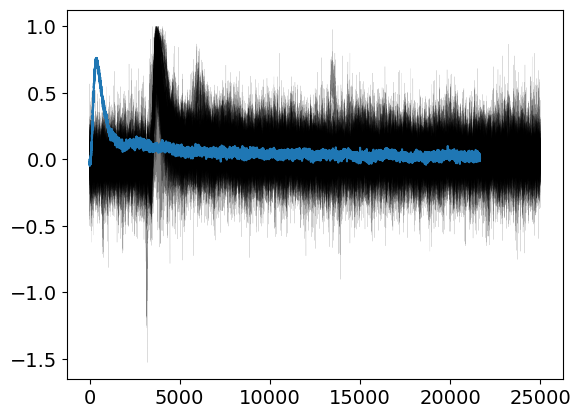

In [15]:
# so we need to subtract off the template * the amplitude at each point... how should I do this, maybe I can do this via a similar technique to the other plot
# first I need to match the template start time up with this, then subtract after scaling with amplitude.
# going to plot all the waveforms here I think
template_2 = np.load('./data/dispersion_curves/cpd2_scintillation.npy')
big_array = np.zeros(shape=(len(waves[0,0,:]), list(above_mask).count(True)))
for ii, (cpd_response, amps) in enumerate(zip(waves[above_mask], cpd_2_scint[above_mask])):
    # we want to normalize by amplirude
    response = cpd_response[1,:] - np.mean(cpd_response[1,0:2000])
    before_pad = 1870
    avg_response = running_average(100, response)
    amps = np.max(avg_response)
    after_pad = int(len(response) - before_pad - len(template_2))
    new_template = np.pad(template_2, (before_pad, after_pad), mode='constant', constant_values=0) * amps

    # plt.plot(response, 'k', label = 'Data')
    # plt.plot(new_template, 'r', label = f'fit {ii}')
    evaporation = response - new_template
    big_array[:, ii] = evaporation/np.max(evaporation)
    plt.plot(evaporation/np.max(evaporation), 'k', label = f'Only Evaporation {ii}', alpha=0.5, linewidth=0.1 )

# plt.ylim(-0.5, 1)
averaged = np.mean(big_array, axis=1)

plt.plot(averaged[3350:])

np.save('./data/dispersion_curves/extreme_deposition.npy', averaged[3350:10000]/np.max(averaged[3350:10000]))


# Template for bad channel

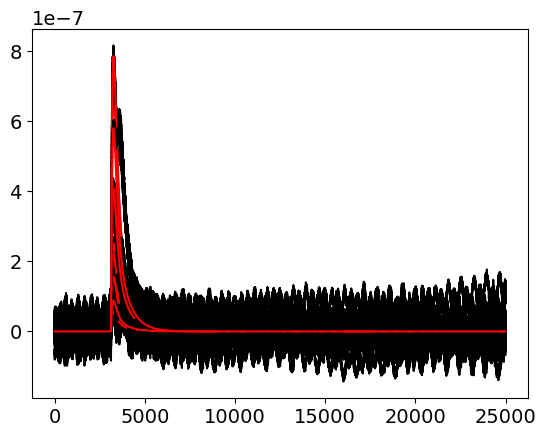

In [29]:
# so we need to subtract off the template * the amplitude at each point... how should I do this, maybe I can do this via a similar technique to the other plot
# first I need to match the template start time up with this, then subtract after scaling with amplitude.
# going to plot all the waveforms here I think
template_2 = np.load('./data/dispersion_curves/cpd2_scintillation.npy')
big_array = np.zeros(shape=(len(waves[0,0,:]), list(above_mask).count(True)))
for ii, (cpd_response, amps) in enumerate(zip(waves[above_mask], cpd_2_scint[above_mask])):
    # we want to normalize by amplirude
    response = cpd_response[0,:] - np.mean(cpd_response[0,0:2000])
    before_pad = 1870
    avg_response = running_average(100, response)
    amps = np.max(avg_response)
    after_pad = int(len(response) - before_pad - len(template_2))
    new_template = np.pad(template_2, (before_pad, after_pad), mode='constant', constant_values=0) * amps

    plt.plot(response, 'k', label = 'Data')
    plt.plot(new_template, 'r', label = f'fit {ii}')
    evaporation = response - new_template
    # big_array[:, ii] = evaporation/np.max(evaporation)
    # plt.plot(evaporation/np.max(evaporation), 'k', label = f'Only Evaporation {ii}', alpha=0.5, linewidth=0.1 )

# plt.ylim(-0.5, 1)
# averaged = np.mean(big_array, axis=1)

# plt.plot(averaged[3350:])

# np.save('./data/dispersion_curves/extreme_deposition.npy', averaged[3350:10000]/np.max(averaged[3350:10000]))


# General Data Template

In [32]:
# so we need to subtract off the template * the amplitude at each point... how should I do this, maybe I can do this via a similar technique to the other plot
# first I need to match the template start time up with this, then subtract after scaling with amplitude.
# going to plot all the waveforms here I think
template_2 = np.load('./data/dispersion_curves/cpd2_scintillation.npy')
big_array = np.zeros(shape=(len(waves[0,0,:]), len(cpd_2_scint)))
for ii, (cpd_response, amps) in enumerate(zip(waves, cpd_2_scint)):
    # we want to normalize by amplirude
    response = cpd_response[1,:] - np.mean(cpd_response[1,0:2000])
    before_pad = 1870
    avg_response = running_average(100, response)
    amps = np.max(avg_response)
    after_pad = int(len(response) - before_pad - len(template_2))
    new_template = np.pad(template_2, (before_pad, after_pad), mode='constant', constant_values=0) * amps

    # plt.plot(response, 'k', label = 'Data')
    # plt.plot(new_template, 'r', label = f'fit {ii}')
    evaporation = response - new_template
    big_array[:, ii] = evaporation/np.max(evaporation)
    plt.plot(evaporation/np.max(evaporation), 'k', label = f'Only Evaporation {ii}', alpha=0.5, linewidth=0.1 )

# plt.ylim(-0.5, 1)
averaged = np.mean(big_array, axis=1)

plt.plot(averaged[3350:])



: 

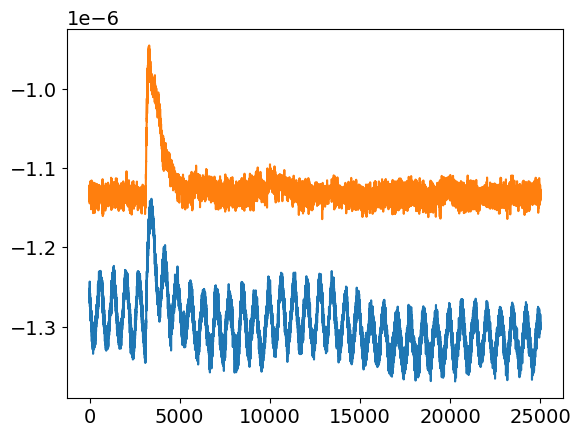

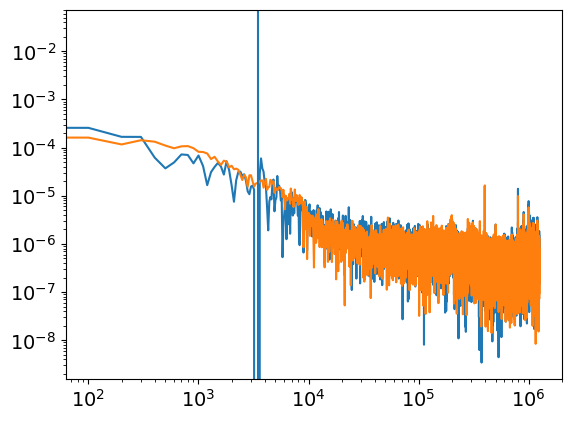

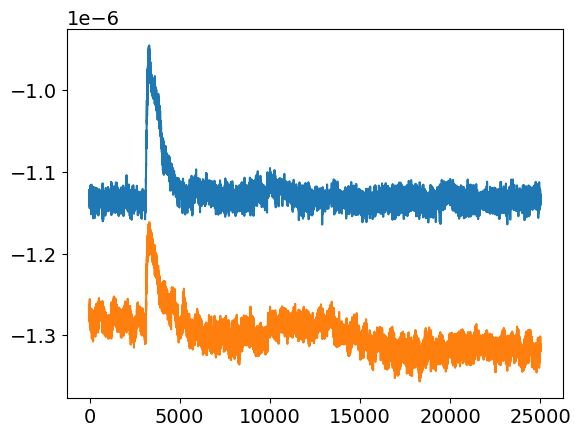

In [ ]:
# let's take the fourier transform of this, then select the bin(s) that are super high. 
example_wave = waves[above_mask, 0,:][1]
no_oscillation = waves[above_mask, 1,:][1]
plt.plot(example_wave, label='Noisy Channel')
plt.plot(no_oscillation, label='Good Channel')
plt.show()

ex_fft = np.fft.rfft(example_wave) 
no_osc = np.fft.rfft(no_oscillation)


ex_freqs = np.fft.rfftfreq(25000, 0.4e-6)

# ex_fft[33:36] = 0
plt.plot(ex_freqs, np.abs(ex_fft))
plt.plot(ex_freqs, np.abs(no_osc))
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.5e3)


# find the inverse fourier transform. 
plt.show()
plt.plot(no_oscillation, label='Good Channel')
example_post = np.fft.irfft(ex_fft)
plt.plot(example_post)

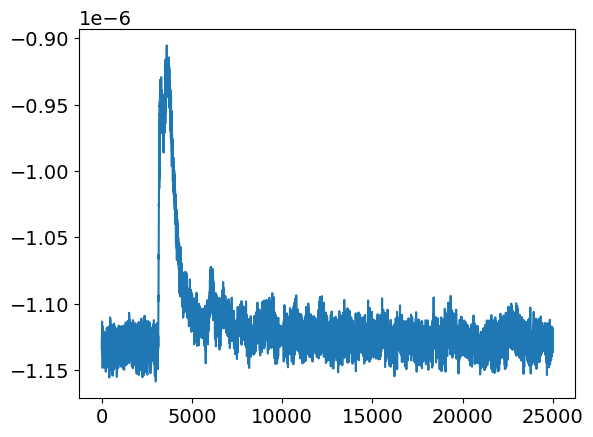

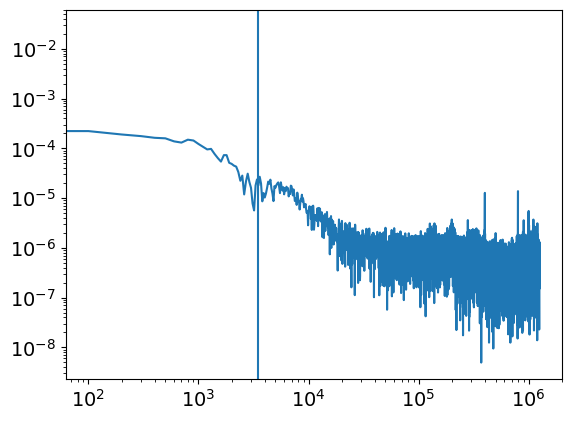

In [18]:
# let's take the fourier transform of this, then select the bin(s) that are super high. 
example_wave = waves[above_mask, 1,:][0]
plt.plot(example_wave)
plt.show()

ex_fft = np.fft.rfft(example_wave) 

ex_freqs = np.fft.rfftfreq(25000, 0.4e-6)

plt.plot(ex_freqs, np.abs(ex_fft))
plt.xscale('log')
plt.yscale('log')
plt.axvline(3.5e3)



In [19]:
# now that I have this, we can calculate a chi-squared. let's save this as a template-like thing.

# Generating a Template


In [20]:
def template(t, t_0, A, B, tau1, tau2, tau3):
    values = A * np.exp(-(t - t_0)/tau1) + B * np.exp(-(t - t_0)/tau2) - (A+B)*np.exp(-(t - t_0)/tau3)
    return np.where(values < 0, 0, values)

In [21]:
t = np.linspace(0, 3, )

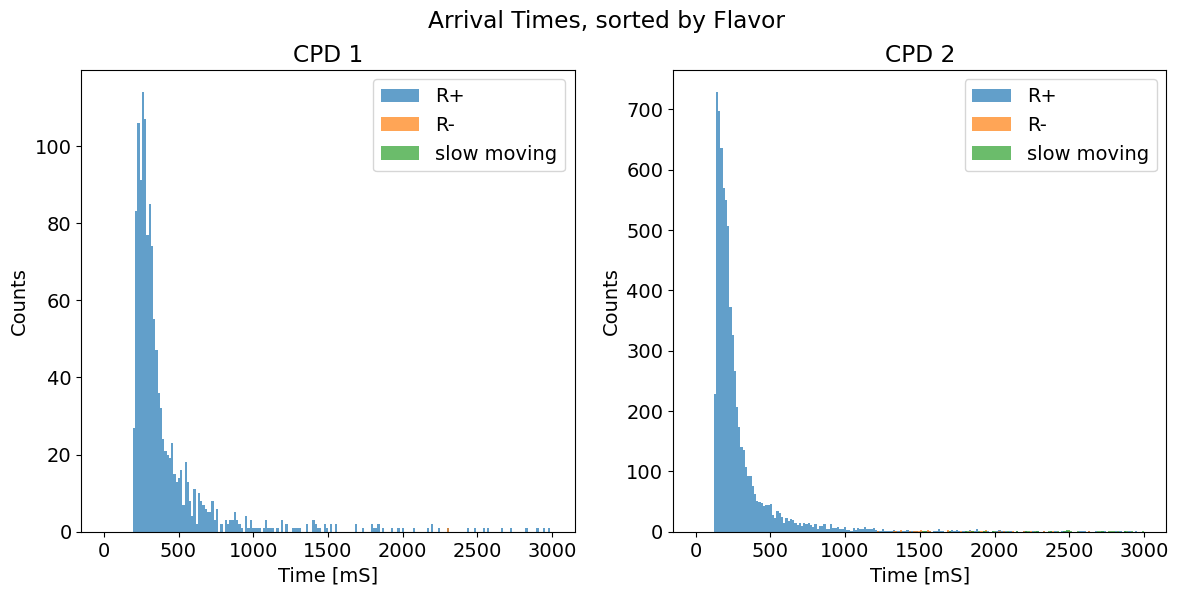

In [22]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_4.pkl', 'rb') as f:
    evap = pickle.load(f)
plot_hist_flavors(evap)

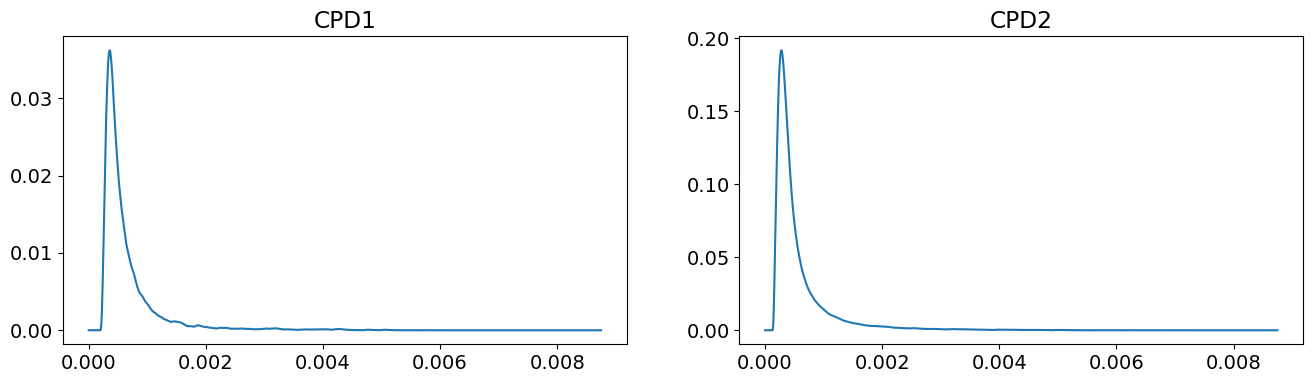

In [23]:
plot_waveform(evap)

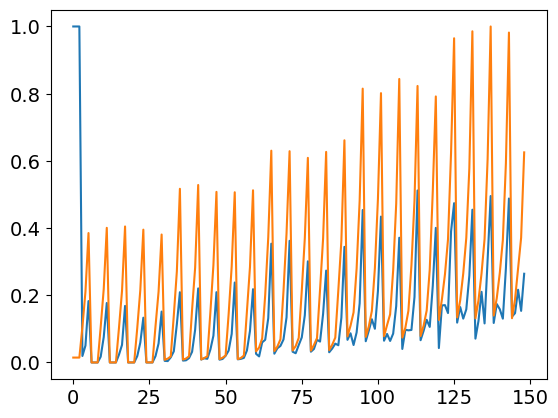

In [24]:
chi_sq = np.load('./data/further_zoom.npy')
plt.plot(chi_sq/np.max(chi_sq, axis=0))

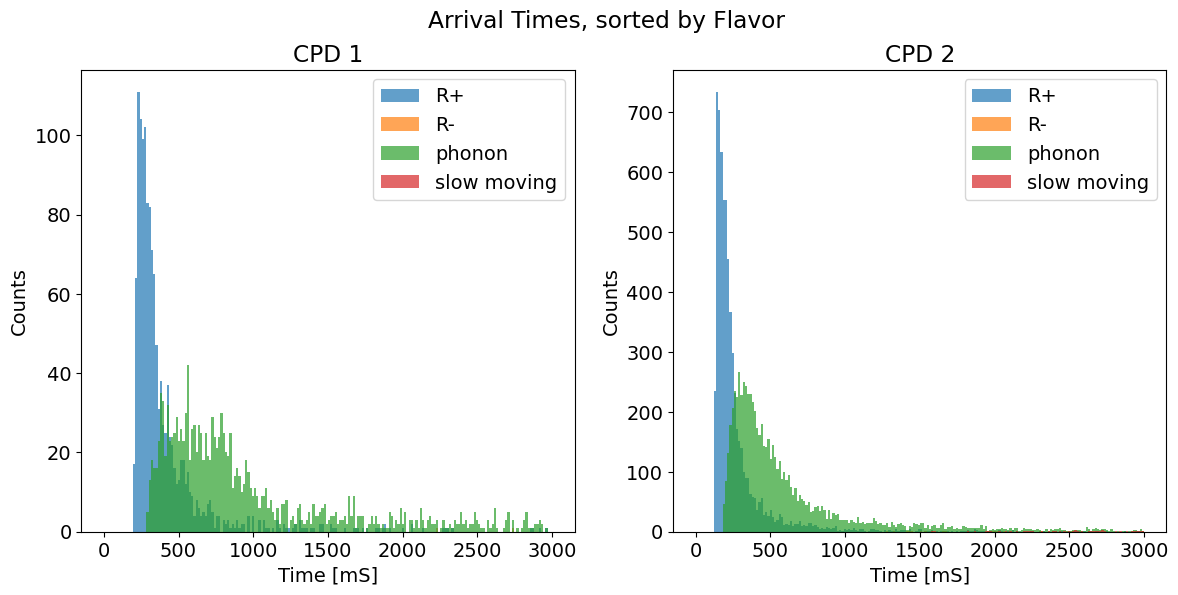

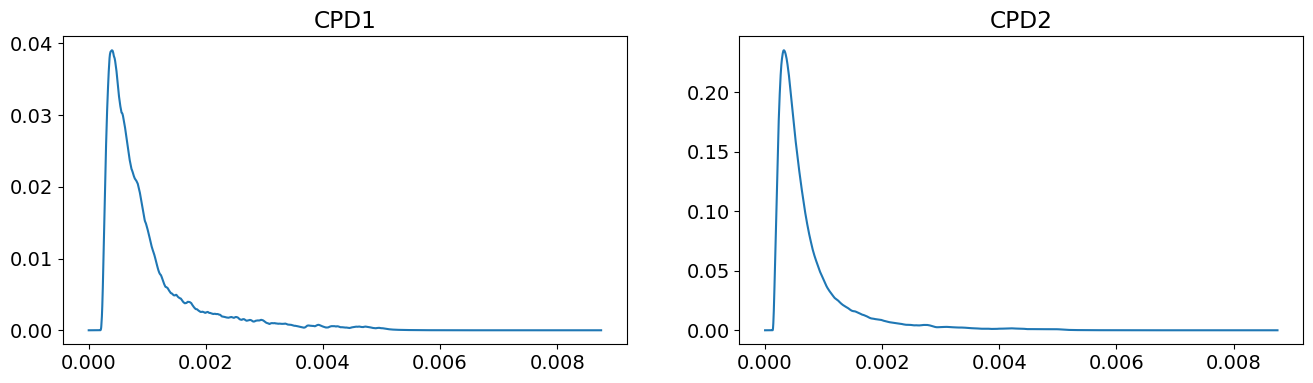

In [25]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_100.pkl', 'rb') as f:
    evap = pickle.load(f)
plot_hist_flavors(evap)
plot_waveform(evap)

489
21874
6650


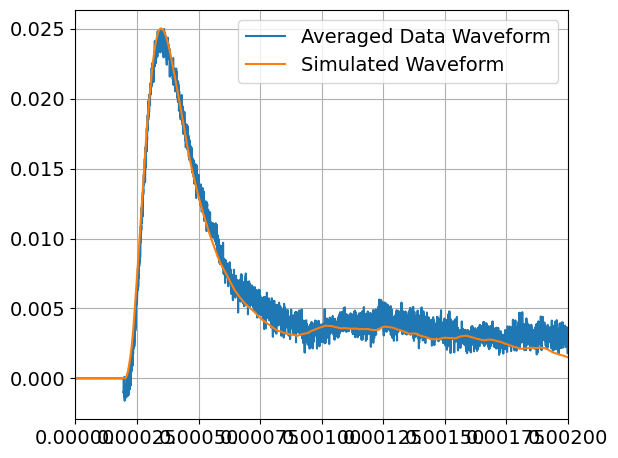

In [26]:
template_1 = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/extreme_deposition.npy')
fig, ax = plt.subplots(1,)
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_9.pkl', 'rb') as file:
    evap = pickle.load(file)
s1, s2 , time =generate_waveform(evap)
peak_1 = np.max(s1)
peak_index_signal_1 = np.argmax(s1)
peak_index_template_1 = np.argmax(template_1)
diff = peak_index_signal_1 - peak_index_template_1
before_pad = int(diff)
print(before_pad)
after_pad = len(s1) - len(template_1) -before_pad


print(len(s1))
print(len(template_1))
if after_pad < 0: 
    new_template_1 = np.pad(template_1, (before_pad, 0 ), mode='constant', constant_values=0)  * peak_1
    s1_padded = np.pad(s1, (0, len(s1) - after_pad - before_pad))

else: 
    new_template_1 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_1



ax.plot(time, new_template_1, label = 'Averaged Data Waveform')
# ax[i].plot(time, new_template_2, label = 'CPD2 template')
ax.plot(time, s1, label='Simulated Waveform')
ax.set_xlim(0, 0.002)
# ax[i].plot(time, s2, label='CPD2 simulation')
ax.legend()
ax.grid()
fig.tight_layout()

363
21874
9375


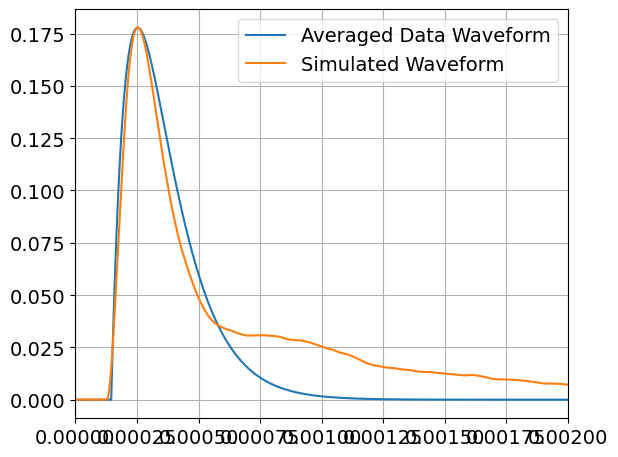

In [27]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[3]



fig, ax = plt.subplots(1,)
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/fit_waveform/trial_305.pkl', 'rb') as file:
    evap = pickle.load(file)
s1, s2 , time =generate_waveform(evap)
peak_1 = np.max(s1)
peak_index_signal_1 = np.argmax(s1)
peak_index_template_1 = np.argmax(template_1)
diff = peak_index_signal_1 - peak_index_template_1
before_pad = int(diff)
print(before_pad)
after_pad = len(s1) - len(template_1) -before_pad


print(len(s1))
print(len(template_1))
if after_pad < 0: 
    new_template_1 = np.pad(template_1, (before_pad, 0 ), mode='constant', constant_values=0)  * peak_1
    s1_padded = np.pad(s1, (0, len(s1) - after_pad - before_pad))

else: 
    new_template_1 = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak_1



ax.plot(time, new_template_1, label = 'Averaged Data Waveform')
# ax[i].plot(time, new_template_2, label = 'CPD2 template')
ax.plot(time, s1, label='Simulated Waveform')
ax.set_xlim(0, 0.002)
# ax[i].plot(time, s2, label='CPD2 simulation')
ax.legend()
ax.grid()
fig.tight_layout()

['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_0.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_1.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_10.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_100.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_101.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_102.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_103.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_104.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_105.npy', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/furt

KeyboardInterrupt: 

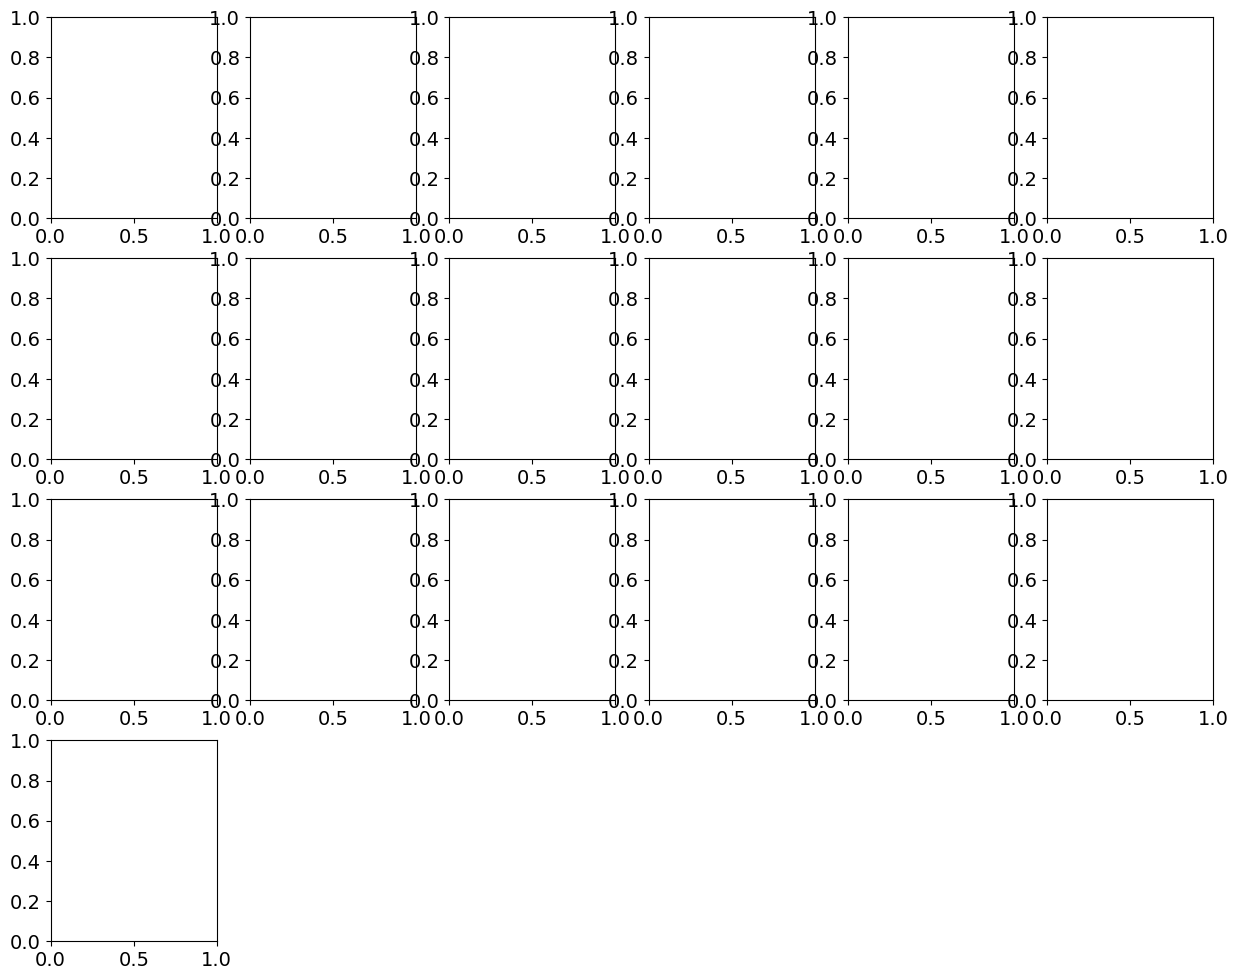

In [28]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_*.pkl')
config_list= glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_*.npy')
print(config_list)

fig, axs = plt.subplots(4, 6 , figsize=(15,12),  sharey=True)
ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_2 = template[3]
chi_squared = np.empty_like(file_list, dtype=float)

for i, f1 in enumerate(file_list):
    with open(f1, 'rb') as file:
        evap = pickle.load(file)
    config_file = np.load(config_list[i], allow_pickle=True).item()
    s1, s2 , time =generate_waveform(evap)
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

    chi_squared[i] = np.sum((s1+1)**2 - (new_template+1)**2/(new_template+1))
    ax[i].plot(time * 1e6, new_template + 1, label = 'Experimental Data')

    ax[i].plot(time * 1e6, s1 + 1, label='Simulation')
    ax[i].set_xlim(0, 3000)
    # ax[i].plot(time, s2, label='CPD2')
    eff = config_file['evap_eff'].astype('str')
    title = 'p='+ eff[0] + ' ,r-=' + eff[1] + ' ,r+= ' + eff[2]
    ax[i].set_title(title, fontsize=13)
    if i==0: ax[i].legend(fontsize=12)
    ax[i].grid()
    ax[i].set_xlabel(r'Time [$\mu$s]', fontsize=12)
fig.suptitle("Example of Multi-parameter Sweep")
fig.tight_layout()
fig.savefig('./data/plots/Testing_different_flavors.png', dpi = 250)

# Analyzing two chi-squared's 

I want to be able to analyze both the channel 1 and channel 2 plots at the same time. 

I think this is fine, let's just assume that the other template (template 2) follows the typical one, as it is physically pretty similar. 



[-0.0294716  -0.0322149  -0.02783029 ...  0.02516091  0.01521501
  0.00974828]


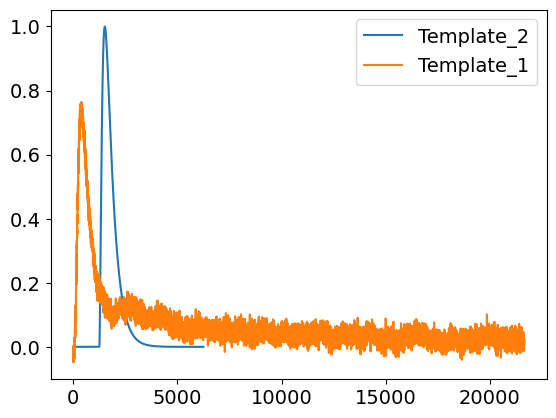

In [ ]:
template_2 = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/template_cpd2_evaporation.npy')

template_1 = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/extreme_deposition.npy')
print(template_1)
plt.plot(template_2, label= 'Template_2')
plt.plot(template_1, label = 'Template_1')
plt.legend()

continued
continued
continued
-858


ValueError: index can't contain negative values

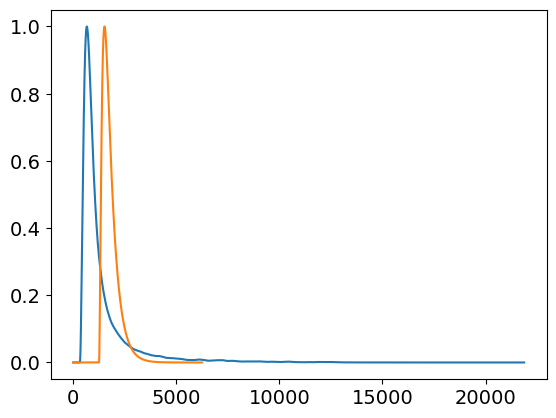

In [ ]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/further_zoom/config_*.npy')
matched_pairs = get_file_map(config_list=config_list, trial_list=trial_list)
template_1 = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/extreme_deposition.npy')
template_2 = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/template_cpd2_evaporation.npy')
chi_squared = np.ones((149, 2), dtype=float)
for num, (config, trial) in matched_pairs.items():
    if num < 3:
        print('continued')
        continue
    with open(trial, 'rb') as file:
        evap = pickle.load(file)
    s1, s2 , time =generate_waveform(evap)
    peak_1 = np.max(s1)
    peak_index_signal_1 = np.argmax(s1)
    peak_index_template_1 = np.argmax(template_1)
    diff_1 = peak_index_signal_1 - peak_index_template_1
    before_pad_1 = int(diff_1)
    after_pad_1 = len(s1) - len(template_1) -before_pad_1
    if after_pad_1 < 0:
        after_pad_1 = 0


    peak_2 = np.max(s2)
    peak_index_signal_2 = np.argmax(s2)
    peak_index_template_2 = np.argmax(template_2)
    diff_2 = peak_index_signal_2 - peak_index_template_2
    before_pad_2 = int(diff_2)
    plt.plot(s2/np.max(s2))
    plt.plot(template_2, )
    print(before_pad_2)
    after_pad_2 = len(s2) - len(template_2) -before_pad_2
    if after_pad_2 < 0:
        after_pad_2 = 0


    new_template_1 = np.pad(template_1, (before_pad_1, after_pad_1), mode='constant', constant_values=0)  * peak_1
    new_template_2 = np.pad(template_2, (before_pad_2, after_pad_2), mode='constant', constant_values=0)  * peak_2
    least_squares = s1[:1600] - (new_template_1[:1600])/np.std(new_template_1[:1600])
    chi_squared[num, 0] = np.sum(least_squares**2)
    chi_squared[num, 1] = np.sum((s2[:1600] - (new_template_2[:1600]))**2)
        # print(f"{num} failed while evaluating the new template")

0.4

# Making Plots for Scott
Specifically for his CDR, he wants the following:

6cm diameter, 3cm depth, 8mm vacuum gap
only a single channel, but record xy positions
these two plots:

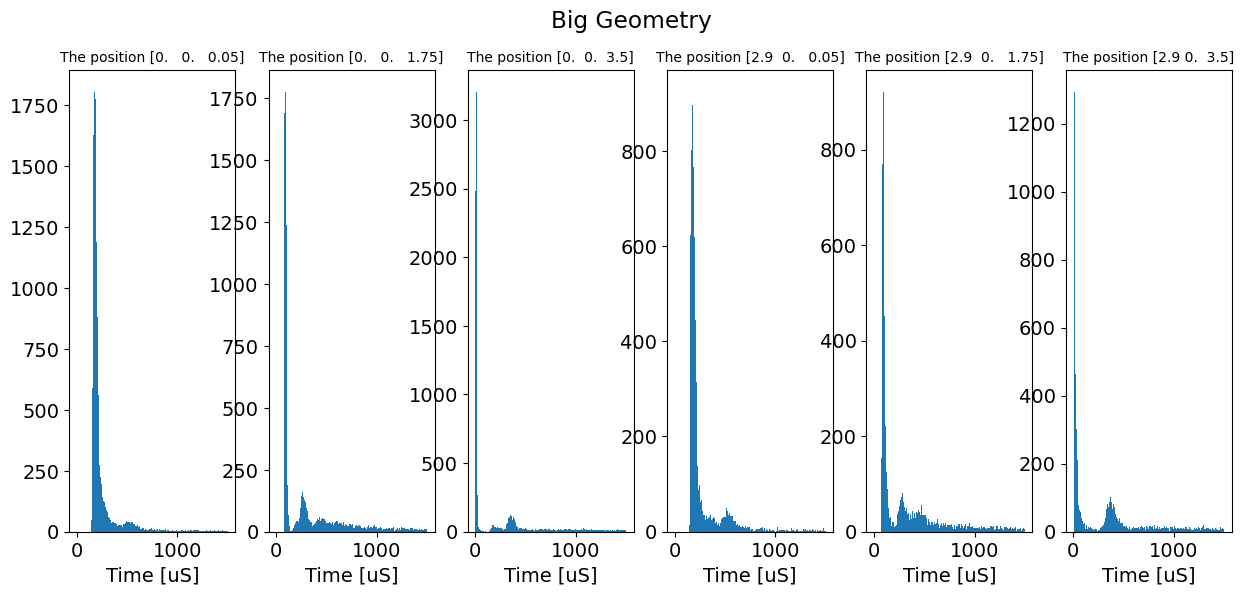

In [ ]:

trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/trial_*.npy')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/config_*.npy')

small_dictionary = get_file_map(config_list, trial_list)
small_dictionary

fig, ax = plt.subplots(1,6, figsize = (15,6))

fig.suptitle("Big Geometry")
for num, (config, trial) in small_dictionary.items():
    trial_data = np.load(trial)
    config = np.load(config, allow_pickle=True).item()
    title = 'The position ' + str(np.round(config['pos'], 2))
    ax[num].hist(trial_data[:,0], bins=200, range=(0,1500))
    ax[num].set_title(title, fontsize=10)
    ax[num].set_xlabel('Time [uS]')




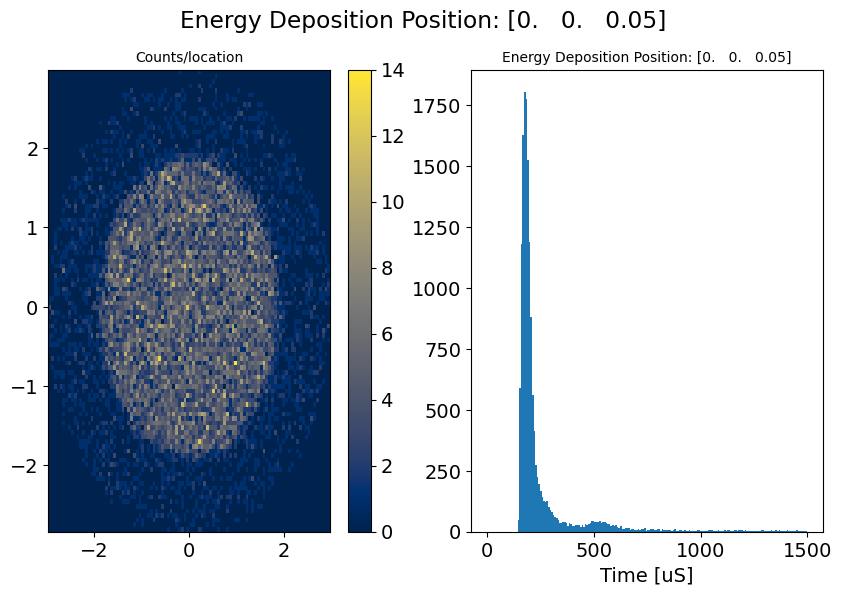

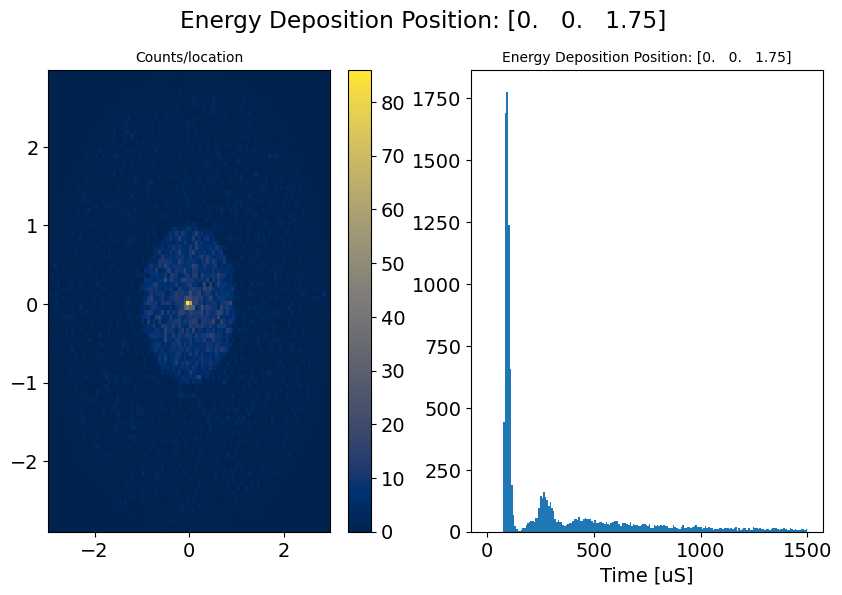

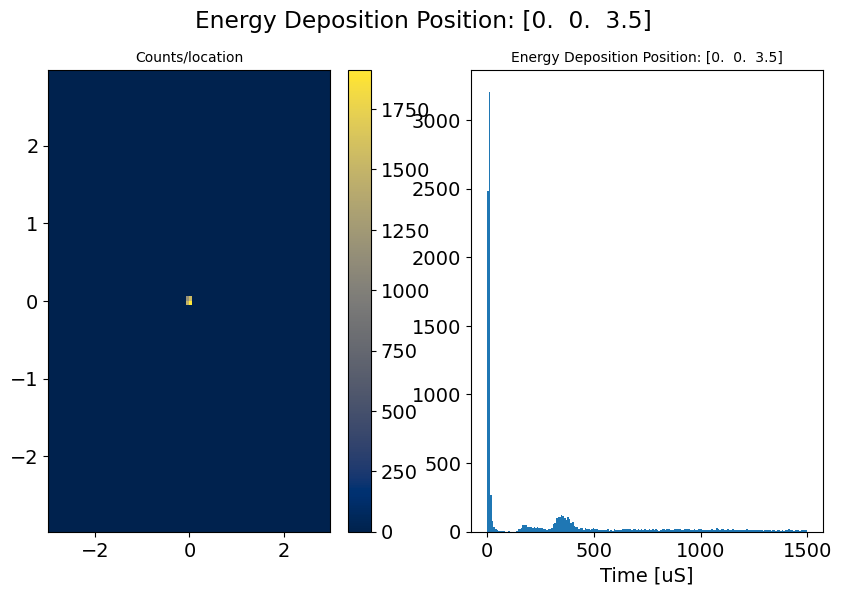

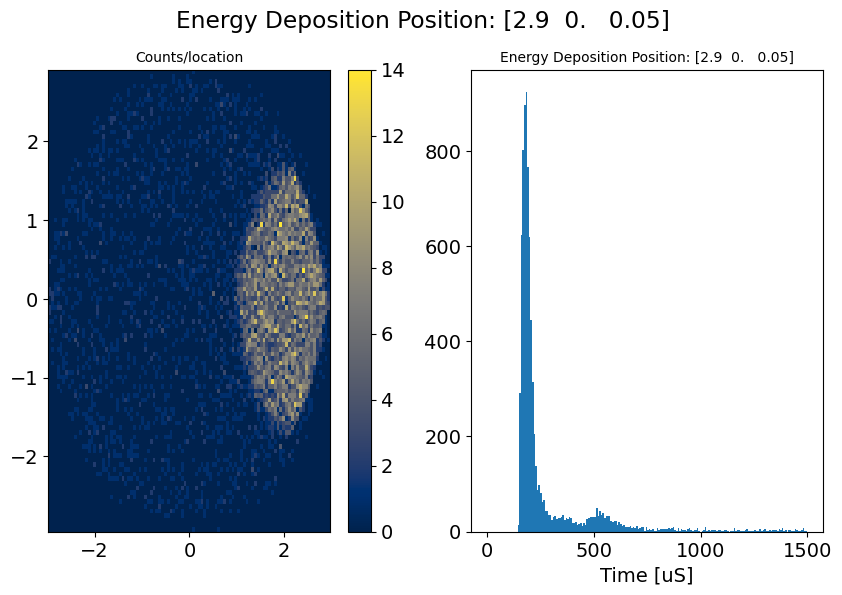

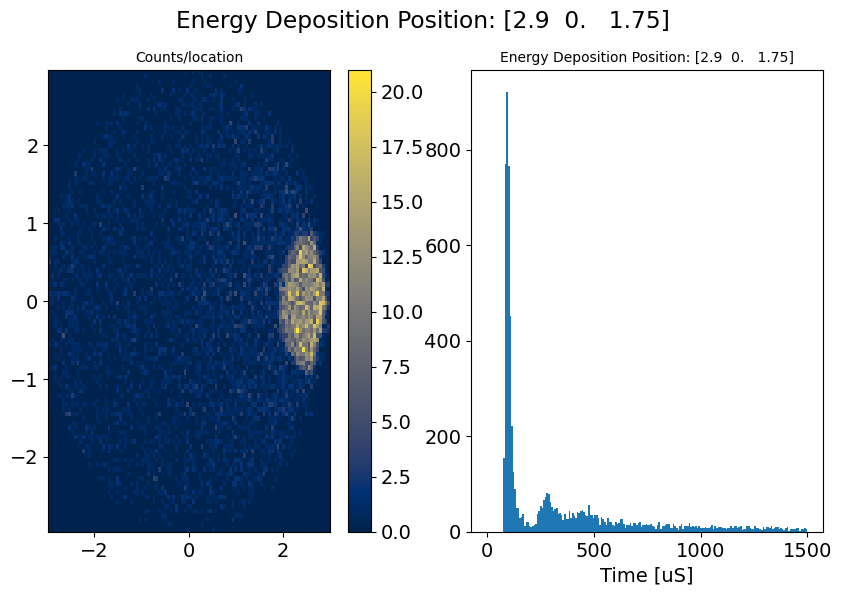

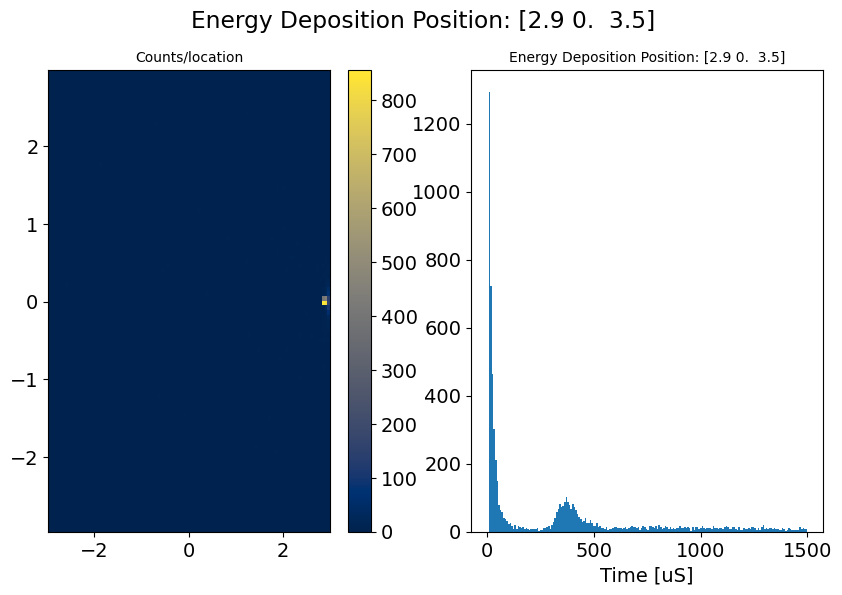

In [ ]:

trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/trial_*.npy')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/big/config_*.npy')

small_dictionary = get_file_map(config_list, trial_list)
small_dictionary


for num, (config, trial) in small_dictionary.items():
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,6))
    # at each point we want to do the histogram like we have been, AND a plot of the x-y arrival positions
    trial_data = np.load(trial)
    config = np.load(config, allow_pickle=True).item()
    title = 'Energy Deposition Position: ' + str(np.round(config['pos'], 2))
    ax1.set_title('Counts/location', fontsize=10)
    h, xe, ye, im = ax1.hist2d(trial_data[:,1], trial_data[:,2], bins=100, cmap='cividis')
    fig.colorbar(im)
    fig.suptitle(title)
    ax2.hist(trial_data[:,0], bins=200, range=(0,1500))
    ax2.set_title(title, fontsize=10)
    ax2.set_xlabel('Time [uS]')




(-0.1, 0.1)

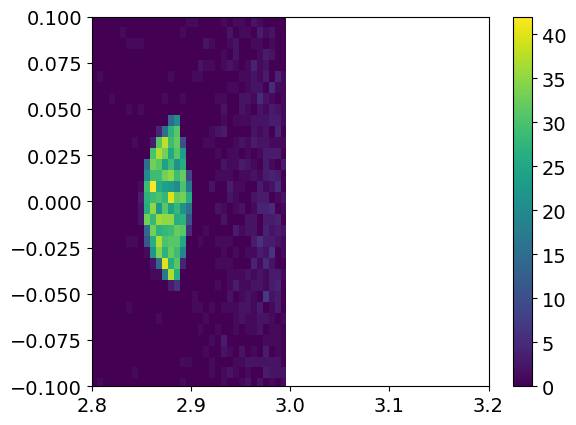

In [ ]:
plt.hist2d(trial_data[:,1], trial_data[:,2], bins=1000)
plt.colorbar()

(array([  2.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   2.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
          1.,   0.,   0.,   2.,   2.,   0.,   0.,   1.,   0.,   0.,   1.,
          1.,   1.,   1.,   2.,   1.,   0.,   4.,   5.,   3.,   3.,   0.,
          3.,   3.,   2.,   3.,   1.,   7.,   6.,   3.,   1.,   2.,   0.,
          1.,   2.,   3.,   2.,   1.,   2.,   4.,   0.,   1.,   3.,   3.,
          0.,   1.,   0.,   1.,   2.,   3.,   4.,   5.,   2.,   2.,   2.,
          3.,   1.,   3.,   4.,   2.,   2.,   5.,   2.,   4.,   1.,   1.,
          7.,   2.,   3.,   3.,   4.,   3.,   1.,   2.,   4.,   5.,   3.,
          4.,   1.,   2.,   4.,   1.,   5.,   5.,   2.,   2.,   2.,   5.,
          5.,   5.,   5.,   1.,   4.,   4.,   2.,   3.,   7.,   4.,   3.,
          8.,   0.,   2.,   5.,   8.,   5.,   5.,   4.,   2.,   6.,   1.,
          3.,   4.,   4.,   7.,   1., 

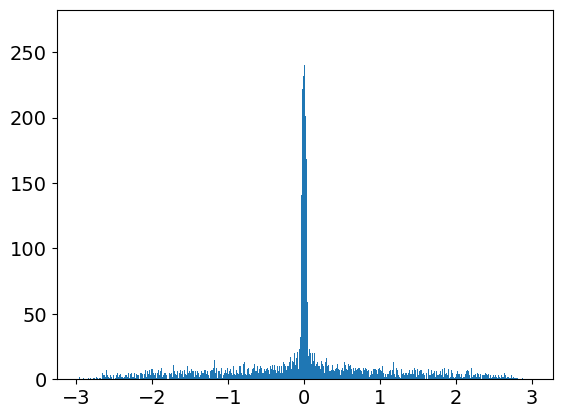

In [ ]:
plt.hist(trial_data[:,2], bins = 1000)

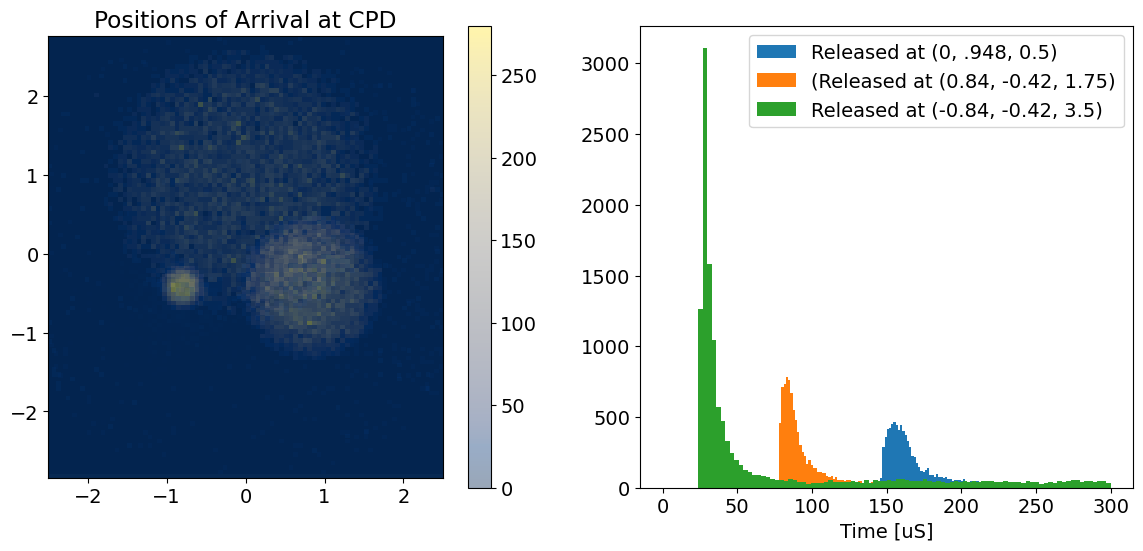

In [ ]:


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,6))
# at each point we want to do the histogram like we have been, AND a plot of the x-y arrival positions
trial_data_1 = np.load('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/pretty_low.pkl.npy')
time_cut = trial_data_1[:,0] < 300
# ax1.set_title('Counts/location', fontsize=10)
h, xe, ye, im = ax1.hist2d(trial_data_1[:,1][time_cut], trial_data_1[:,2][time_cut], range=[[-3,3],[-3,3]], bins=100, alpha = 0.95,   cmap='cividis')
# fig.suptitle(title)
ax2.hist(trial_data_1[:,0][time_cut], bins=200, range=(0,300), label = 'Released at (0, .948, 0.5)')
# ax2.set_title(title, fontsize=10)
ax2.set_xlabel('Time [uS]')

trial_data_2 = np.load('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/pretty_middle.pkl.npy')
# ax1.set_title('Counts/location', fontsize=10)
time_cut = trial_data_2[:,0] < 300
h, xe, ye, im = ax1.hist2d(trial_data_2[:,1][time_cut], trial_data_2[:,2][time_cut], bins=100, alpha = 0.6,   cmap='cividis')
# fig.suptitle(title)
ax2.hist(trial_data_2[:,0][time_cut], bins=200, range=(0,300), label = '(Released at (0.84, -0.42, 1.75)')
# ax2.set_title(title, fontsize=10)
ax2.set_xlabel('Time [uS]')

trial_data_3 = np.load('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/pretty_high.pkl.npy')
# ax1.set_title('Counts/location', fontsize=10)
time_cut = trial_data_3[:,0] < 300

h, xe, ye, im = ax1.hist2d(trial_data_3[:,1][time_cut], trial_data_3[:,2][time_cut], bins=100, alpha = 0.4,  cmap='cividis')
ax1.set_aspect('equal')
ax1.set_xlim(-2.5, 2.5)
ax1.set_title('Positions of Arrival at CPD')
ax1.set_xlabel('')
# total_data_x = np.concatenate((trial_data_1[:,1],trial_data_2[:,1], trial_data_3[:,1]))
# total_data_y = np.concatenate((trial_data_1[:,2],trial_data_2[:,2], trial_data_3[:,2]))

# h, xe, ye, im = ax1.hist2d(total_data_x, total_data_y, bins=100,  cmap='cividis')
# fig.suptitle(title)

ax2.hist(trial_data_3[:,0][time_cut], bins=100, range=(0,300), label = 'Released at (-0.84, -0.42, 3.5)')
ax2.legend()
# ax2.set_title(title, fontsize=10)
ax2.set_xlabel('Time [uS]')
fig.colorbar(im)

Text(0.5, 0, 'Time [uS]')

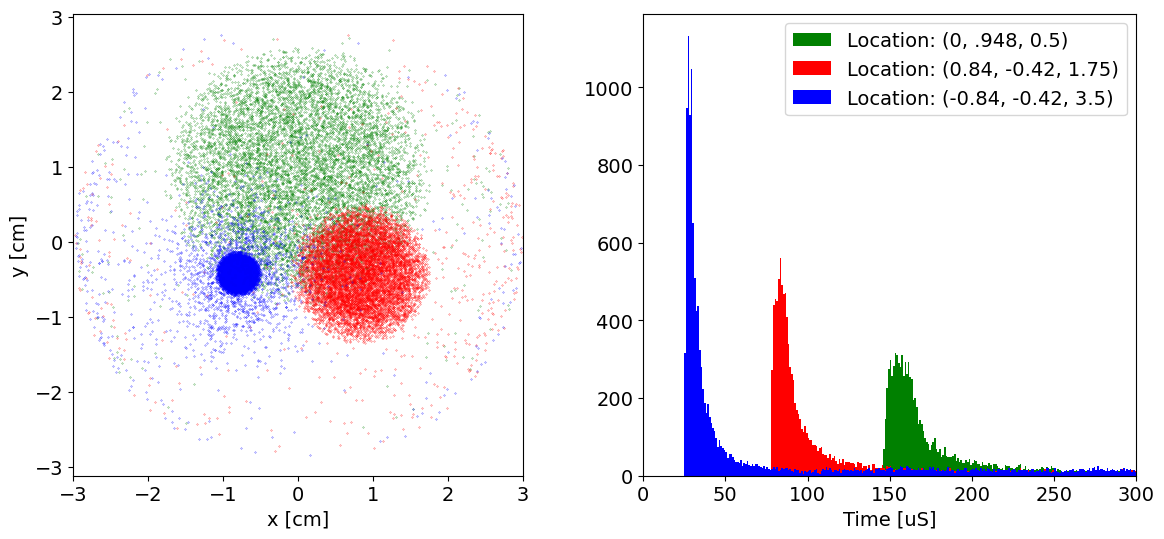

In [35]:


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,6))
# at each point we want to do the histogram like we have been, AND a plot of the x-y arrival positions
trial_data_1 = np.load('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/pretty_low.pkl.npy')
time_cut = trial_data_1[:,0] < 300
# ax1.set_title('Counts/location', fontsize=10)
a = 0.05
ax1.scatter(trial_data_1[:,1][time_cut], trial_data_1[:,2][time_cut], s = a, color = 'g' )
# fig.suptitle(title)
ax2.hist(trial_data_1[:,0][time_cut], bins=500, range=(0,500), color = 'g', label = 'Location: (0, .948, 0.5)')
# ax2.set_title(title, fontsize=10)
ax2.set_xlabel('Time [uS]')

trial_data_2 = np.load('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/pretty_middle.pkl.npy')
# ax1.set_title('Counts/location', fontsize=10)
time_cut = trial_data_2[:,0] < 300
ax1.scatter(trial_data_2[:,1][time_cut], trial_data_2[:,2][time_cut] , s = a, color = 'r'   )
# fig.suptitle(title)
ax2.hist(trial_data_2[:,0][time_cut], bins=500, range=(0,500),color = 'r',  label = 'Location: (0.84, -0.42, 1.75)')
# ax2.set_title(title, fontsize=10)
ax2.set_xlabel('Time [uS]')

trial_data_3 = np.load('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/review_plots/pretty_high.pkl.npy')
# ax1.set_title('Counts/location', fontsize=10)
time_cut = trial_data_3[:,0] < 300

ax1.scatter(trial_data_3[:,1][time_cut], trial_data_3[:,2][time_cut],   s = a, color = 'b' )
ax1.set_aspect('equal')
ax1.set_xlim(-3, 3)
# ax1.set_title('Positions of Arrival at CPD')
ax1.set_xlabel('x [cm]')
ax1.set_ylabel('y [cm]')
# total_data_x = np.concatenate((trial_data_1[:,1],trial_data_2[:,1], trial_data_3[:,1]))
# total_data_y = np.concatenate((trial_data_1[:,2],trial_data_2[:,2], trial_data_3[:,2]))

# h, xe, ye, im = ax1.scatter(total_data_x, total_data_y, bins=100,  cmap='cividis')
# fig.suptitle(title)

ax2.hist(trial_data_3[:,0][time_cut], bins=500, range=(0,500), color = 'b', label = 'Location: (-0.84, -0.42, 3.5)')
ax2.legend()
ax2.set_xlim(0, 300)
# ax2.set_title(title, fontsize=10)
ax2.set_xlabel('Time [uS]')